# Importing libraries

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 8)
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
from kmodes.kmodes import KModes
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score
from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import log_loss
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn.metrics import make_scorer
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn import metrics
from sklearn.utils import resample

# PCA Scatterplot

In [36]:
#df_pca = df_dummy.iloc[:, :-1]
#scaler = StandardScaler()
#scaled_df = df_pca.copy()
#scaled_df=pd.DataFrame(scaler.fit_transform(scaled_df), columns=scaled_df.columns)

In [48]:
#pca = PCA(n_components=50)

#fit PCA model to data
#pca_fit = pca.fit(scaled_df)

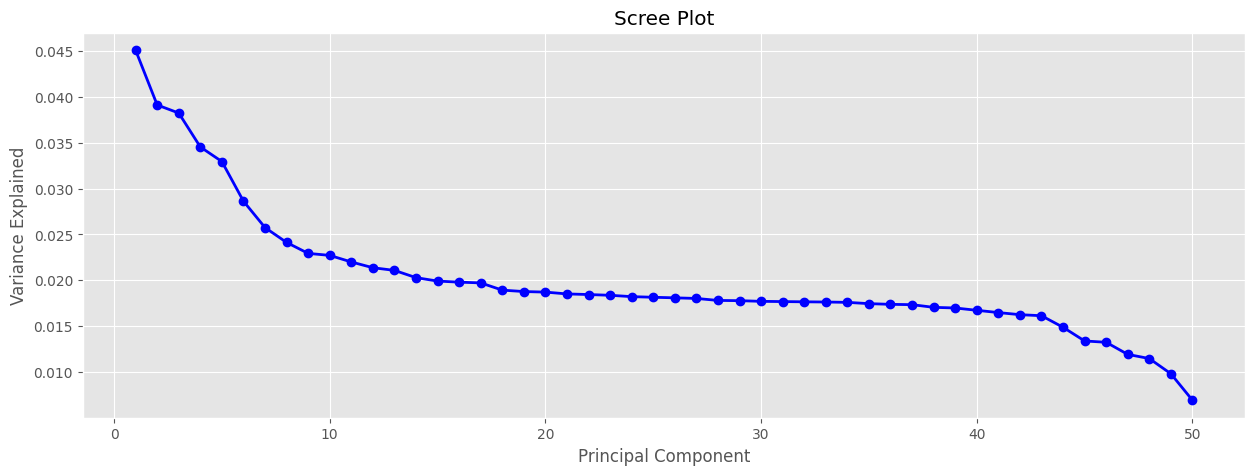

[0.04506175 0.03909845 0.03822045 0.03452738 0.03293613 0.02862007
 0.02574622 0.02412728 0.02293502 0.02271851 0.02200152 0.02137483
 0.02108505 0.02029529 0.0199204  0.01980219 0.01972181 0.01893463
 0.01877997 0.01871887 0.01852182 0.01845359 0.01837212 0.0182252
 0.01815738 0.01809474 0.01802903 0.01781212 0.01778651 0.01771275
 0.0176865  0.01766208 0.01763945 0.01760209 0.01746223 0.01738641
 0.01735051 0.01706018 0.01698991 0.01673734 0.01649038 0.01626039
 0.01614758 0.0148908  0.01339857 0.01325273 0.01193677 0.01148189
 0.00982921 0.00694387]


In [49]:
#PC_values = np.arange(pca.n_components_) + 1
#plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
#plt.title('Scree Plot')
#plt.xlabel('Principal Component')
#plt.ylabel('Variance Explained')
#plt.show()
#print(pca.explained_variance_ratio_)

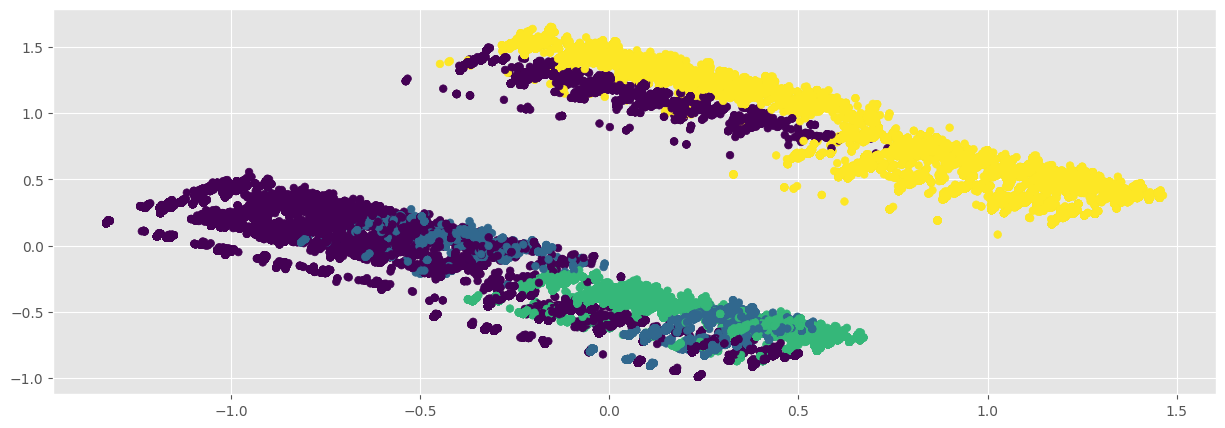

In [62]:
#pca = PCA(n_components=45)
# Turn the dummified df into two columns with PCA
#plot_columns = pca.fit_transform(df_dummy.iloc[:,:-1])

# Plot based on the two dimensions, and shade by cluster label
#plt.scatter(x=plot_columns[:,1], y=plot_columns[:,0], c=df_dummy["Clusters"], s=30)
#plt.show()

# OLD Train/Test split, rebalancing and making models on entire dataframe.

In [310]:
#STRATIFIED K FOLD 
fen_train, fen_test = train_test_split(fen_df2, test_size =0.25, random_state = 10)

In [311]:
print(fen_train.shape)
print(fen_test.shape)

(54167, 55)
(18056, 55)


In [ ]:
print(fen_train["Death"].count())
print(fen_train["Death"].value_counts(normalize = True))
fen_train["Death"].value_counts()

54167
Accidental Drug Poisoning      0.939816
Undetermined Drug Poisoning    0.035760
Unknown                        0.016634
Suicide Drug Poisoning         0.007791
Name: Death, dtype: float64


Accidental Drug Poisoning      50907
Undetermined Drug Poisoning     1937
Unknown                          901
Suicide Drug Poisoning           422
Name: Death, dtype: int64

In [ ]:
def determine_num_samples(records, unique_records, proportion):
    x = int((proportion * records - unique_records) / (1 - proportion))
    return x

In [ ]:
num_samples_long_duration = determine_num_samples(len(fen_train), 1937, 0.3)
print("Long Duration Upsample samples to add: ", num_samples_long_duration)

Long Duration Upsample samples to add:  20447


In [ ]:
to_resample = fen_train.loc[fen_train['Death'] =="Undetermined Drug Poisoning"]

In [316]:
our_resample = to_resample.sample(n = 20447 , replace = True)
fen_train_rebal = pd.concat([fen_train, our_resample])

In [317]:
# resampled distribution of race
fen_train_rebal['Death'].value_counts()

Accidental Drug Poisoning      50907
Undetermined Drug Poisoning    22384
Unknown                          901
Suicide Drug Poisoning           422
Name: Death, dtype: int64

In [318]:
x_train = fen_train_rebal.drop('Death', axis=1)
y_train = fen_train_rebal['Death']

In [319]:
x_test = fen_test.drop('Death', axis=1)
y_test = fen_test['Death']

In [320]:
#Baseline for Accidental
print((((y_train.value_counts().max())/len(y_train))*100), end='%')

68.22714235934275%

In [321]:
s_base = y_train.value_counts()['Undetermined Drug Poisoning']
print(((s_base/len(y_train))*100), end='%')

29.99973195378883%

In [ ]:
rf01 = RandomForestClassifier(n_estimators = 30,criterion="gini").fit(x_train,y_train)

prediction_rf01 = rf01.predict(x_train)
print(rf01.score(x_test,y_test))

0.856723526805494
